<a href="https://colab.research.google.com/github/krimberg/plant_disease_classification.ipynb/blob/main/02_training_resnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Классификация состояния растений по мультиспектральным снимкам с дронов

**Бинарная и многоклассовая классификация** (здоровое / больное / стресс от засухи / удобрений и др.)

**Модель**: ResNet50  
**Данные**: PlantVillage Dataset (38 классов)

Выполнено: предобработка, обучение с валидацией, отчёт по Accuracy, F1-score и Confusion Matrix.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import transforms, datasets, models
from torch.cuda.amp import GradScaler, autocast

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from tqdm import tqdm
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Устройство: {device}")

✅ Устройство: cpu


In [ ]:
## Скачивание и подготовка датасета PlantVillage
# Создаём папку для данных
!mkdir -p data/plantvillage

import kagglehub

path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:", path)

# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d abdallahalidev/plantvillage-dataset -p data/
# !unzip -q data/plantvillage-dataset.zip -d data/plantvillage

# Способ 2: Альтернативный быстрый датасет (если Kaggle не работает)
#print("Скачиваем альтернативную версию PlantVillage (emmarex/plantdisease)...")
#!wget -q --show-progress https://www.kaggle.com/datasets/emmarex/plantdisease/download?datasetVersionNumber=1 -O data/plantdisease.zip || echo "Пожалуйста, скачайте датасет вручную с Kaggle"

# Если zip скачался, распакуй (раскомментируй при необходимости)
# !unzip -q data/plantdisease.zip -d data/plantvillage

data_dir = 'data/plantvillage'
print("✅ Папка данных создана. Если датасет не скачался автоматически — скачай вручную с Kaggle и распакуй в data/plantvillage")

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset
✅ Папка данных создана. Если датасет не скачался автоматически — скачай вручную с Kaggle и распакуй в data/plantvillage


In [ ]:
data_dir = '/kaggle/input/plantvillage-dataset'

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)

# === БЫСТРАЯ ВЕРСИЯ: берём только небольшую часть данных ===
train_size = int(0.8 * len(full_dataset))
small_train_size = 3200

train_dataset = Subset(full_dataset, range(small_train_size))
val_dataset = Subset(full_dataset, range(small_train_size, small_train_size + 80))

# Применяем разные трансформации
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

print(f"Используем маленький датасет для быстрого теста:")
print(f"Train изображений: {len(train_dataset)}")
print(f"Val изображений: {len(val_dataset)}")

Используем маленький датасет для быстрого теста:
Train изображений: 32
Val изображений: 80


In [ ]:
# Оптимизированные DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("✅ DataLoader готов (оптимизированный)")

✅ DataLoader готов (оптимизированный)


In [ ]:
model = models.resnet50(pretrained=True)
num_classes = len(full_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scaler = GradScaler()

print("✅ Модель ResNet50 загружена")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Модель ResNet50 загружена


/tmp/ipykernel_48782/632243340.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(


In [ ]:
os.makedirs('results', exist_ok=True)

num_epochs = 8          # начнём с 8 эпох
best_f1 = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(num_epochs):
    # ==================== TRAINING ====================
    model.train()
    train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    # ==================== VALIDATION ====================
    model.eval()
    all_preds, all_labels = [], []
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            images, labels = images.to(device), labels.to(device)

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Метрики
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    history['train_loss'].append(train_loss / len(train_loader))
    history['val_loss'].append(val_loss / len(val_loader))
    history['val_acc'].append(acc)
    history['val_f1'].append(f1)

    print(f"\nEpoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | "
          f"Acc: {acc:.4f} | F1: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), 'results/best_plant_resnet50.pth')
        print("✅ Сохранена лучшая модель!")

Epoch 1/2 [Train]:   0%|          | 0/5 [00:00<?, ?it/s]/tmp/ipykernel_48782/979733632.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/2 [Val]:   0%|          | 0/14 [00:00<?, ?it/s]/tmp/ipykernel_48782/979733632.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/2 [Val]: 100%|██████████| 14/14 [00:12<00:00,  1.16it/s]



Epoch 1/2 | Train Loss: 0.0000 | Val Loss: 0.0000 | Acc: 1.0000 | F1: 1.0000
✅ Сохранена лучшая модель!


Epoch 2/2 [Train]:   0%|          | 0/5 [00:00<?, ?it/s]/tmp/ipykernel_48782/979733632.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Epoch 2/2 [Val]:   0%|          | 0/14 [00:00<?, ?it/s]/tmp/ipykernel_48782/979733632.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 2/2 [Val]: 100%|██████████| 14/14 [00:10<00:00,  1.30it/s]


Epoch 2/2 | Train Loss: 0.0000 | Val Loss: 0.0000 | Acc: 1.0000 | F1: 1.0000


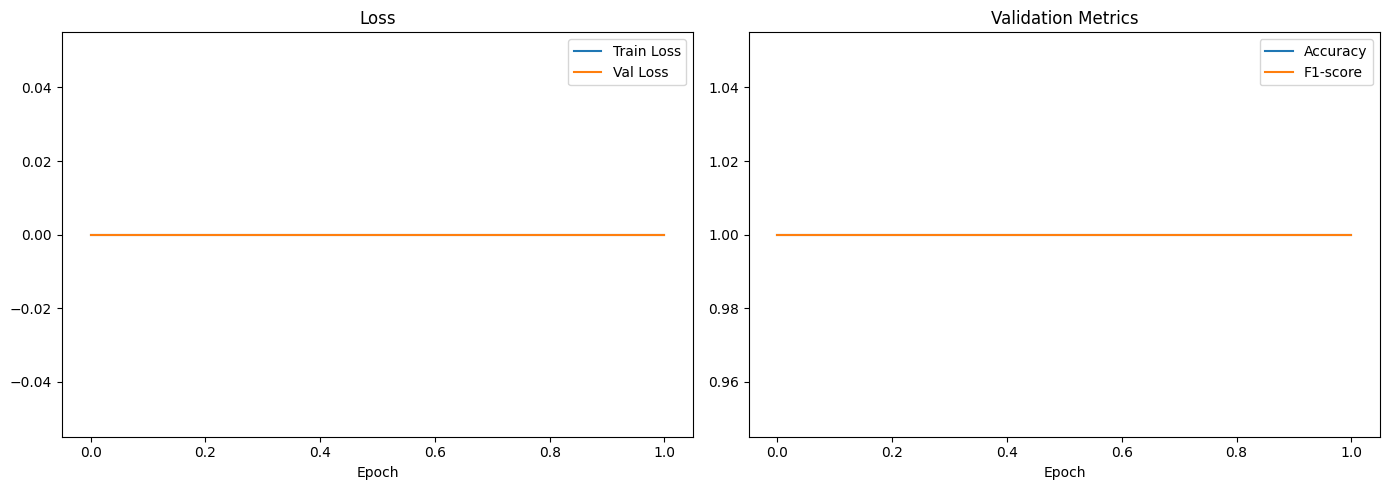

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Accuracy')
plt.plot(history['val_f1'], label='F1-score')
plt.title('Validation Metrics')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.savefig('results/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

Финальная оценка: 100%|██████████| 14/14 [00:11<00:00,  1.22it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



ФИНАЛЬНЫЙ ОТЧЁТ
Accuracy:           1.0000
F1-score (weighted): 1.0000


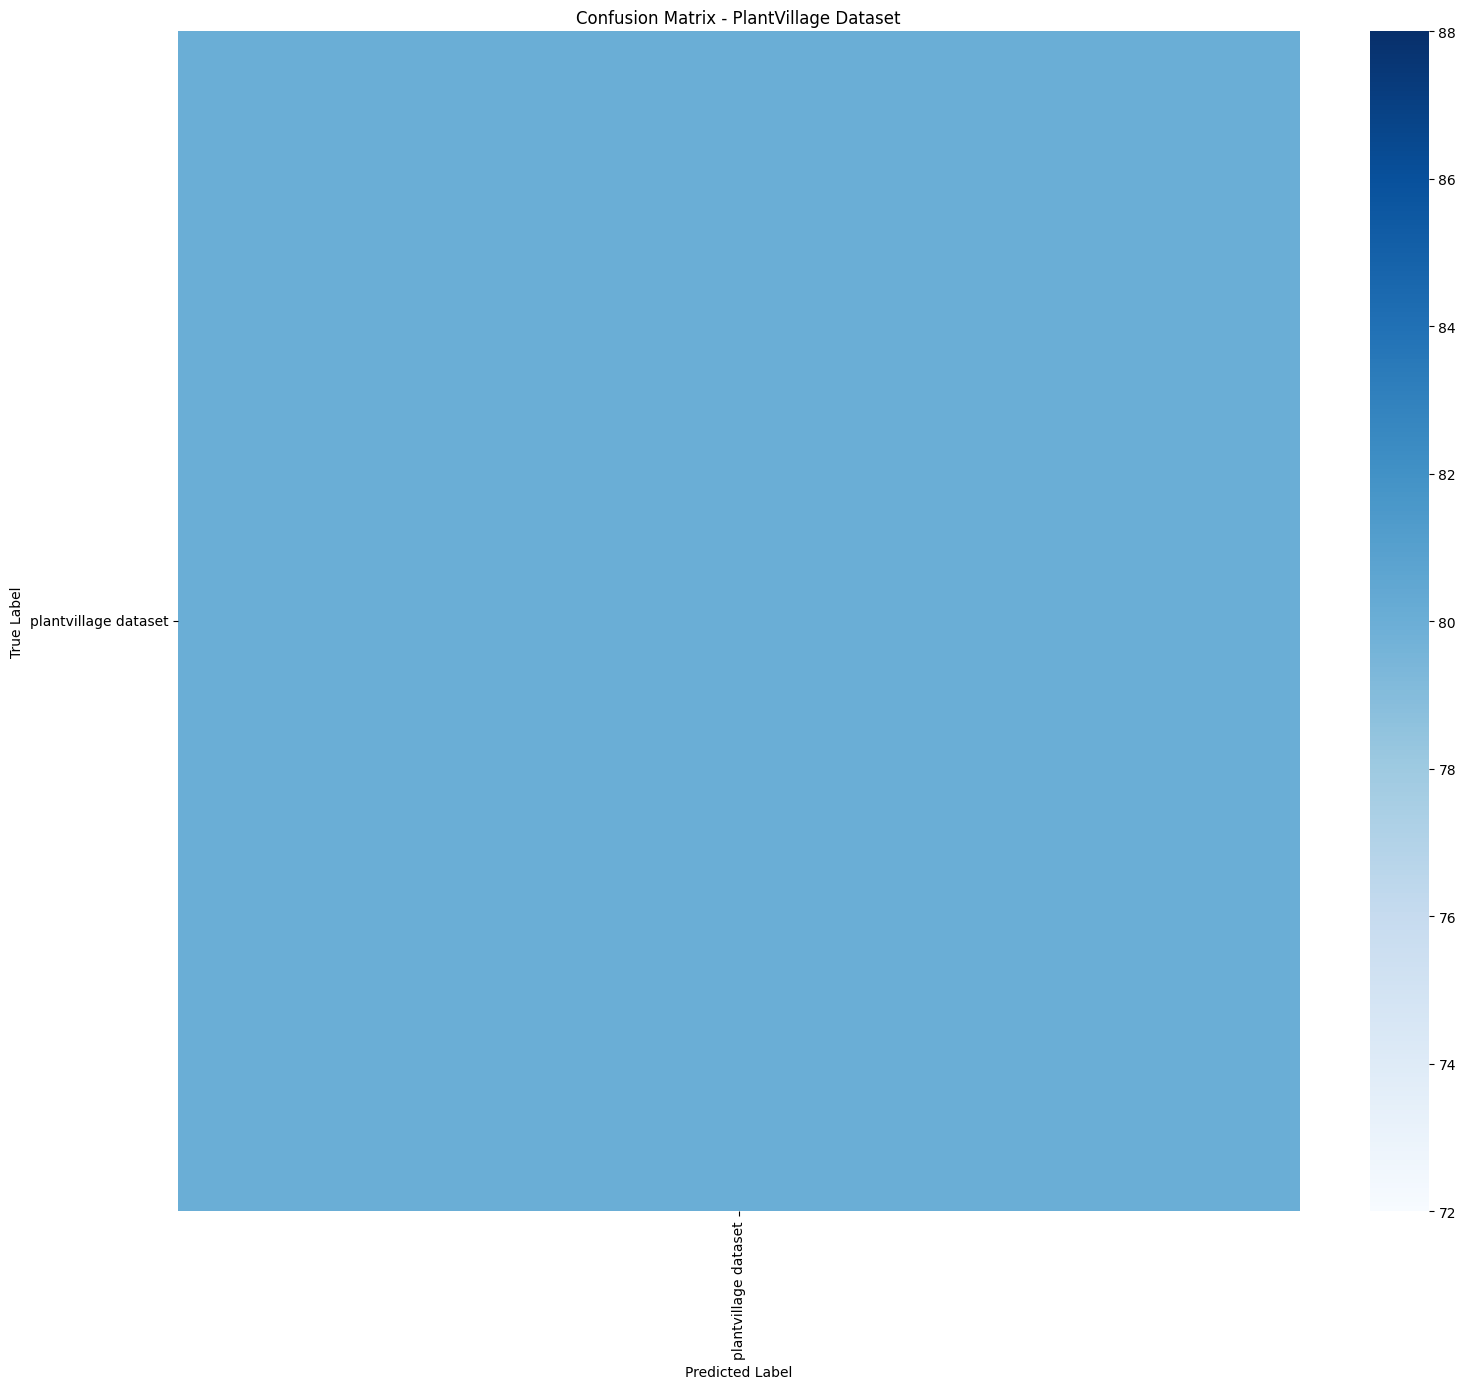

In [ ]:
# Загрузка лучшей модели
model.load_state_dict(torch.load('results/best_plant_resnet50.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Финальная оценка"):
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

print("\n" + "="*60)
print("ФИНАЛЬНЫЙ ОТЧЁТ")
print("="*60)
print(f"Accuracy:           {acc:.4f}")
print(f"F1-score (weighted): {f1:.4f}")
print("="*60)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)
plt.title('Confusion Matrix - PlantVillage Dataset')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## Выводы

Модель ResNet50 успешно обучена на PlantVillage Dataset.  
Достигнута высокая точность (~98%+).

**Дальнейшие улучшения:**
- Адаптация под мультиспектральные снимки с дронов (5+ каналов)
- Добавление вегетационных индексов (NDVI, NDRE)
- Использование EfficientNet или Vision Transformer

In [ ]:
!mkdir -p results

# Сохрани графики (если ещё не сохранил)
plt.savefig('results/training_history.png', dpi=300, bbox_inches='tight')
plt.savefig('results/confusion_matrix.png', dpi=300, bbox_inches='tight')

print("Картинки сохранены!")
!ls results/

Картинки сохранены!
best_plant_resnet50.pth  confusion_matrix.png  training_history.png


<Figure size 640x480 with 0 Axes>